# 39 Train Diffusion-GAN and Make Images - DIBaS

This notebook trains Diffusion-GAN only for the minority cocci balancing arm. It does not overwrite StyleGAN2-ADA, StyleGAN3-T, or R3GAN outputs.

## Locked Protocol

- Binary task stays fixed: cocci = 0 and bacilli = 1.
- One GAN is trained per training fold.
- Each GAN sees only the same-fold real minority cocci 256x256 patches.
- The generated count exactly matches the minority top-up needed to balance the CNN train fold.
- Snapshot selection uses the same sparse KID rule as the other GAN arms: 40, 80, 120, 160, and 200 kimg.
- Diffusion-GAN-specific diffusion noise settings are recorded as architecture-specific settings.
- Outputs are saved under separate diffusion_gan folders and manifests.


In [1]:
from pathlib import Path
import csv
import json
import math
import os
import re
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

# This helper keeps the notebook runnable from the repo root or from notebooks/.
def find_repo_root(start_path: Path) -> Path:
    current_path = start_path.resolve()
    for candidate in [current_path, *current_path.parents]:
        if (candidate / "notebooks").exists() and (candidate / "manifests").exists():
            return candidate
    raise RuntimeError("Could not find the FYP2 repository root.")

REPO_ROOT = find_repo_root(Path.cwd())
MANIFESTS_DIR = REPO_ROOT / "manifests"
RESULTS_DIR = REPO_ROOT / "results"
CHECKPOINTS_DIR = REPO_ROOT / "checkpoints"
GAN_PATCHES_DIR = REPO_ROOT / "gan_patches_256" / "dibas"
GAN_IMAGES_256_DIR = REPO_ROOT / "gan_images_256" / "diffusion_gan" / "dibas"
GAN_IMAGES_224_DIR = REPO_ROOT / "gan_images_224" / "diffusion_gan" / "dibas"
THIRD_PARTY_DIR = REPO_ROOT / "third_party"
DIFFUSION_GAN_ROOT_CANDIDATES = [THIRD_PARTY_DIR / "Diffusion-GAN", THIRD_PARTY_DIR / "diffusion-gan"]
DIFFUSION_GAN_ROOT = next((path for path in DIFFUSION_GAN_ROOT_CANDIDATES if path.exists()), None)
if DIFFUSION_GAN_ROOT is None:
    raise FileNotFoundError(
        "Missing Diffusion-GAN folder. Clone the official repo into third_party/Diffusion-GAN before running this notebook."
    )

DIFFUSION_GAN_DIR = DIFFUSION_GAN_ROOT / "diffusion-stylegan2"
if not DIFFUSION_GAN_DIR.exists():
    raise FileNotFoundError(f"Missing diffusion-stylegan2 folder: {DIFFUSION_GAN_DIR}")

NOTEBOOK_TAG = "39_train_diffusion_gan_make_images_dibas"
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
NOTEBOOK_CHECKPOINTS_DIR = CHECKPOINTS_DIR / NOTEBOOK_TAG
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
GAN_IMAGES_256_DIR.mkdir(parents=True, exist_ok=True)
GAN_IMAGES_224_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "dibas"
SEED = 2026
DIFFUSION_GAN_RANDOM_SEED = 0
FOLDS_TO_RUN = [1, 2, 3, 4, 5]
GAN_PATCH_SIZE = 256
CNN_PATCH_SIZE = 224
GAN_BATCH_SIZE = 8
GAN_WORKERS = 3
GAN_KIMG = 200
# Diffusion-GAN train.py does not expose --tick. The inherited StyleGAN2 training loop uses 4 kimg per tick.
# With snap=10, the saved sparse snapshots should be 40, 80, 120, 160, and 200 kimg.
TICK_KIMG = 4
SNAP_TICKS = 10
SNAPSHOT_SELECTION_KIMG = [40, 80, 120, 160, 200]
GAN_MIRROR = True
DIFFUSION_GAN_CFG = "auto"
DIFFUSION_GAN_AUG = "no"
DIFFUSION_GAN_TARGET = 0.6
DIFFUSION_GAN_NOISE_SD = 0.05
DIFFUSION_GAN_TS_DIST = "priority"
DIFFUSION_GAN_ADA_KIMG = 100
KID_METRIC_NAME = "kid50k_full"
GENERATE_START_SEED = 10000
LONG_COMMAND_NOTEBOOK_MODE = "smart"
KID_OPENMP_DUPLICATE_OK = True
ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS = False

# Diffusion-GAN is run in the same Windows fyp2 environment used for StyleGAN3/R3GAN on RTX 4060.
DIFFUSION_GAN_WINDOWS_PYTHON = Path("C:/Users/FYP2610/anaconda3/envs/fyp2/python.exe")
DIFFUSION_GAN_TORCH_CUDA_ARCH_LIST = "8.0+PTX"
DIFFUSION_GAN_EXTENSIONS_DIR = CHECKPOINTS_DIR / "torch_extensions_diffusion_gan_sm80ptx"
DIFFUSION_GAN_EXTENSIONS_DIR.mkdir(parents=True, exist_ok=True)

if os.name == "nt":
    PYTHON_EXE = DIFFUSION_GAN_WINDOWS_PYTHON
    if not PYTHON_EXE.exists():
        raise FileNotFoundError(f"Could not find the Diffusion-GAN Python executable: {PYTHON_EXE}")
    DIFFUSION_GAN_ENV_ROOT = PYTHON_EXE.parent
    CONDA_EXE = DIFFUSION_GAN_ENV_ROOT.parent.parent / "Scripts" / "conda.exe"
    if not CONDA_EXE.exists():
        raise FileNotFoundError(f"Could not find conda.exe: {CONDA_EXE}")
    if shutil.which("cl") is None:
        raise EnvironmentError(
            "cl.exe was not found. Start Jupyter from the Visual Studio 2022 Developer Command Prompt, "
            "then open this notebook again."
        )
else:
    PYTHON_EXE = Path(sys.executable)
    DIFFUSION_GAN_ENV_ROOT = None
    CONDA_EXE = None

DIFFUSION_GAN_EXTRA_ENV = {
    "TORCH_CUDA_ARCH_LIST": DIFFUSION_GAN_TORCH_CUDA_ARCH_LIST,
    "TORCH_EXTENSIONS_DIR": str(DIFFUSION_GAN_EXTENSIONS_DIR),
}
if KID_OPENMP_DUPLICATE_OK:
    DIFFUSION_GAN_EXTRA_ENV["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# This helper ensures Windows subprocesses really run inside the selected conda environment.
def build_python_command(*python_args: str):
    if os.name == "nt":
        return [
            str(CONDA_EXE),
            "run",
            "--no-capture-output",
            "-p",
            str(DIFFUSION_GAN_ENV_ROOT),
            "python",
            *python_args,
        ]
    return [str(PYTHON_EXE), *python_args]

def build_diffusion_gan_command(script_name: str, *script_args: str):
    return build_python_command(script_name, *script_args)

In [2]:
# This helper reads a CSV file into a plain list of rows.
def read_csv_rows(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV file: {csv_path}")
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

# This helper writes a CSV file with a stable header.
def write_csv_rows(csv_path: Path, rows, fieldnames, allow_existing=True):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    if csv_path.exists() and not allow_existing:
        raise FileExistsError(f"Refusing to overwrite existing CSV file: {csv_path}")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# This helper writes one small JSON file with clean formatting.
def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

# This helper stores paths in repo-relative form so the outputs stay portable.
def as_repo_relative(repo_root: Path, path_value: Path) -> str:
    return str(path_value.resolve().relative_to(repo_root.resolve())).replace(chr(92), "/")

# This helper refuses to overwrite generated image folders unless we explicitly allow it.
def safe_prepare_output_dir(output_dir: Path):
    if output_dir.exists() and any(output_dir.iterdir()):
        if not ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS:
            raise FileExistsError(
                f"Refusing to overwrite existing Diffusion-GAN output folder: {output_dir}. "
                "Set ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS=True only if you intentionally want to rerun this notebook."
            )
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

# This helper refuses to continue from an old training run unless we explicitly allow it.
def safe_prepare_checkpoint_parent(output_dir: Path):
    if output_dir.exists() and any(path.is_dir() for path in output_dir.iterdir()):
        if not ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS:
            raise FileExistsError(
                f"Refusing to reuse existing Diffusion-GAN checkpoint folder: {output_dir}. "
                "Move the old folder or set ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS=True only if this is intentional."
            )
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

# This helper decides which command lines matter enough to echo in the notebook.
def should_echo_command_line(line_text: str, line_index: int, notebook_mode: str) -> bool:
    if notebook_mode == "all":
        return True
    if notebook_mode == "quiet":
        return False
    if line_index <= 25:
        return True
    lowered = line_text.lower()
    important_markers = [
        "training for",
        "tick ",
        "sec/kimg",
        "snapshot",
        "saved",
        "kid50k_full",
        "generating image for seed",
        "traceback",
        "runtimeerror",
        "error:",
        "done",
    ]
    return any(marker in lowered for marker in important_markers)

# This helper runs a subprocess, streams useful lines to the notebook, and saves a full log to disk.
def run_command(command_parts, workdir: Path, live_log_path: Path, notebook_mode: str = "smart", extra_env=None):
    live_log_path.parent.mkdir(parents=True, exist_ok=True)
    command_env = os.environ.copy()
    if extra_env is not None:
        command_env.update(extra_env)

    process = subprocess.Popen(
        command_parts,
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=command_env,
    )

    start_time = time.time()
    output_tail = []
    printed_line_count = 0
    suppressed_line_count = 0
    total_line_count = 0

    with live_log_path.open("w", encoding="utf-8") as log_handle:
        for line in process.stdout:
            total_line_count += 1
            output_tail.append(line)
            output_tail = output_tail[-200:]
            log_handle.write(line)
            log_handle.flush()

            line_text = line.rstrip()
            if should_echo_command_line(line_text, total_line_count, notebook_mode):
                print(line_text)
                printed_line_count += 1
            else:
                suppressed_line_count += 1

    returncode = process.wait()
    duration_seconds = round(time.time() - start_time, 2)
    return {
        "command": " ".join(str(item) for item in command_parts),
        "returncode": returncode,
        "duration_seconds": duration_seconds,
        "printed_line_count": printed_line_count,
        "suppressed_line_count": suppressed_line_count,
        "total_line_count": total_line_count,
        "log_path": as_repo_relative(REPO_ROOT, live_log_path),
        "output_tail": "".join(output_tail),
    }

In [3]:
# We record small compatibility fixes for PyTorch 2.11 without changing the Diffusion-GAN method.
def patch_text_file_once(file_path: Path, replacements):
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file to patch: {file_path}")

    original_text = file_path.read_text(encoding="utf-8")
    updated_text = original_text
    applied = []

    for old_text, new_text, reason in replacements:
        if old_text in updated_text:
            updated_text = updated_text.replace(old_text, new_text)
            applied.append({"old_text": old_text, "new_text": new_text, "reason": reason})

    if updated_text != original_text:
        backup_path = file_path.with_name(file_path.name + ".fyp2_backup")
        if not backup_path.exists():
            backup_path.write_text(original_text, encoding="utf-8")
        file_path.write_text(updated_text, encoding="utf-8")
        status = "patched"
    else:
        backup_path = None
        status = "already_ok_or_pattern_not_present"

    return {
        "file_path": as_repo_relative(REPO_ROOT, file_path),
        "status": status,
        "backup_path": as_repo_relative(REPO_ROOT, backup_path) if backup_path else None,
        "applied_replacements": applied,
    }

def patch_numpy_removed_aliases(root_dir: Path):
    # NumPy 2.x removed old aliases such as np.int. This only updates compatibility names.
    alias_replacements = [
        (r"\bnp\.int\b", "int", "NumPy 2.x removed np.int; use the built-in int."),
        (r"\bnp\.float\b", "float", "NumPy 2.x removed np.float; use the built-in float."),
        (r"\bnp\.bool\b", "bool", "NumPy 2.x removed np.bool; use the built-in bool."),
    ]
    patch_rows = []
    for file_path in sorted(root_dir.rglob("*.py")):
        original_text = file_path.read_text(encoding="utf-8")
        updated_text = original_text
        applied = []
        for old_pattern, new_text, reason in alias_replacements:
            if re.search(old_pattern, updated_text):
                updated_text = re.sub(old_pattern, new_text, updated_text)
                applied.append({"old_text": old_pattern, "new_text": new_text, "reason": reason})
        if updated_text != original_text:
            backup_path = file_path.with_name(file_path.name + ".fyp2_numpy_backup")
            if not backup_path.exists():
                backup_path.write_text(original_text, encoding="utf-8")
            file_path.write_text(updated_text, encoding="utf-8")
            patch_rows.append({
                "file_path": as_repo_relative(REPO_ROOT, file_path),
                "status": "patched",
                "backup_path": as_repo_relative(REPO_ROOT, backup_path),
                "applied_replacements": applied,
            })
    if not patch_rows:
        patch_rows.append({
            "file_path": as_repo_relative(REPO_ROOT, root_dir),
            "status": "already_ok_or_pattern_not_present",
            "backup_path": None,
            "applied_replacements": [],
        })
    return patch_rows

def patch_custom_ops_loader(file_path: Path):
    # PyTorch 2.x returns the compiled extension module directly from cpp_extension.load.
    # Older StyleGAN2-derived code imports the module by name afterwards, which can fail on Windows.
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file to patch: {file_path}")
    original_text = file_path.read_text(encoding="utf-8")
    updated_lines = []
    applied = []
    for line in original_text.splitlines(True):
        stripped_line = line.lstrip()
        indent = line[:len(line) - len(stripped_line)]
        if "module = module = torch.utils.cpp_extension.load(" in line:
            line = line.replace("module = module = torch.utils.cpp_extension.load(", "module = torch.utils.cpp_extension.load(")
            applied.append({"old_text": "module = module = torch.utils.cpp_extension.load(", "new_text": "module = torch.utils.cpp_extension.load(", "reason": "Remove accidental duplicate module assignment."})
        elif stripped_line.startswith("torch.utils.cpp_extension.load("):
            line = indent + "module = " + stripped_line
            applied.append({"old_text": "torch.utils.cpp_extension.load(", "new_text": "module = torch.utils.cpp_extension.load(", "reason": "Use the module object returned by PyTorch extension loader."})
        if "module = importlib.import_module(module_name)" in line:
            line = line.replace("module = importlib.import_module(module_name)", "# module is returned by torch.utils.cpp_extension.load above")
            applied.append({"old_text": "module = importlib.import_module(module_name)", "new_text": "# module is returned by torch.utils.cpp_extension.load above", "reason": "Avoid importing compiled extension by name from sys.path."})
        updated_lines.append(line)
    updated_text = "".join(updated_lines)
    if updated_text != original_text:
        backup_path = file_path.with_name(file_path.name + ".fyp2_custom_ops_backup")
        if not backup_path.exists():
            backup_path.write_text(original_text, encoding="utf-8")
        file_path.write_text(updated_text, encoding="utf-8")
        status = "patched"
    else:
        backup_path = None
        status = "already_ok_or_pattern_not_present"
    return {
        "file_path": as_repo_relative(REPO_ROOT, file_path),
        "status": status,
        "backup_path": as_repo_relative(REPO_ROOT, backup_path) if backup_path else None,
        "applied_replacements": applied,
    }

def patch_diffusion_gan_snapshot_names(file_path: Path):
    # Diffusion-GAN saves every network snapshot as network-snapshot.pkl by default.
    # We need kimg-specific snapshot files so KID-based snapshot selection is traceable.
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file to patch: {file_path}")
    original_text = file_path.read_text(encoding="utf-8")
    replacement_text = "snapshot_pkl = os.path.join(run_dir, f'network-snapshot-{cur_nimg//1000:06d}.pkl')"
    replacement_candidates = [
        "snapshot_pkl = misc.get_ckpt_path(run_dir)",
        "snapshot_pkl = get_ckpt_path(run_dir)",
    ]
    applied = []
    updated_text = original_text
    if replacement_text not in updated_text:
        for old_text in replacement_candidates:
            if old_text in updated_text:
                updated_text = updated_text.replace(old_text, replacement_text)
                applied.append({"old_text": old_text, "new_text": replacement_text, "reason": "Save kimg-specific snapshots for fixed KID selection."})
                break
        if not applied:
            raise RuntimeError(
                "Could not find the Diffusion-GAN snapshot save line to patch. "
                "Open training/training_loop.py and check the snapshot_pkl assignment."
            )
    if updated_text != original_text:
        backup_path = file_path.with_name(file_path.name + ".fyp2_snapshot_backup")
        if not backup_path.exists():
            backup_path.write_text(original_text, encoding="utf-8")
        file_path.write_text(updated_text, encoding="utf-8")
        status = "patched"
    else:
        backup_path = None
        status = "already_ok_or_pattern_not_present"
    return {
        "file_path": as_repo_relative(REPO_ROOT, file_path),
        "status": status,
        "backup_path": as_repo_relative(REPO_ROOT, backup_path) if backup_path else None,
        "applied_replacements": applied,
    }

patch_report = {
    "notebook_tag": NOTEBOOK_TAG,
    "patch_date": time.strftime("%Y-%m-%d"),
    "reason": "Compatibility with the Windows fyp2 environment and traceable kimg-specific snapshot files. Network, loss, data, seeds, kimg, and selection protocol are unchanged.",
    "patches": [],
}

patch_report["patches"].append(patch_text_file_once(
    DIFFUSION_GAN_DIR / "train.py",
    [
        ("betas=[0,0.99]", "betas=[0.0,0.99]", "PyTorch 2.11 requires Adam betas to be floats, not ints."),
        ("betas=[0, 0.99]", "betas=[0.0, 0.99]", "PyTorch 2.11 requires Adam betas to be floats, not ints."),
    ],
))

patch_report["patches"].append(patch_text_file_once(
    DIFFUSION_GAN_DIR / "torch_utils" / "misc.py",
    [
        ("super().__init__(dataset)", "super().__init__()", "Newer PyTorch Sampler no longer accepts dataset in object.__init__."),
        ("super().__init__(None)", "super().__init__()", "Newer PyTorch Sampler no longer accepts a data_source argument in object.__init__."),
    ],
))

patch_report["patches"].append(patch_custom_ops_loader(DIFFUSION_GAN_DIR / "torch_utils" / "custom_ops.py"))

patch_report["patches"].append(patch_diffusion_gan_snapshot_names(DIFFUSION_GAN_DIR / "training" / "training_loop.py"))

patch_report["patches"].extend(patch_numpy_removed_aliases(DIFFUSION_GAN_DIR))

write_json(NOTEBOOK_RESULTS_DIR / "diffusion_gan_compatibility_patch_report.json", patch_report)
display(pd.DataFrame(patch_report["patches"]))

# This smoke check confirms that the selected Python environment can see CUDA before long training starts.
env_report = run_command(
    build_python_command(
        "-c",
        "import sys, numpy as np, torch; print(sys.version); print(np.__version__); print(torch.__version__); print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))",
    ),
    DIFFUSION_GAN_DIR,
    NOTEBOOK_RESULTS_DIR / "diffusion_gan_environment_check.log",
    notebook_mode="all",
    extra_env=DIFFUSION_GAN_EXTRA_ENV,
)
write_json(NOTEBOOK_RESULTS_DIR / "diffusion_gan_environment_check_report.json", env_report)
if env_report["returncode"] != 0:
    raise RuntimeError("Diffusion-GAN environment check failed. Read diffusion_gan_environment_check.log before continuing.")

,file_path,status,backup_path,applied_replacements
0,third_party/Diffusion-GAN/diffusion-stylegan2/...,already_ok_or_pattern_not_present,None,[]
1,third_party/Diffusion-GAN/diffusion-stylegan2/...,already_ok_or_pattern_not_present,None,[]
2,third_party/Diffusion-GAN/diffusion-stylegan2/...,already_ok_or_pattern_not_present,None,[]
3,third_party/Diffusion-GAN/diffusion-stylegan2/...,patched,third_party/Diffusion-GAN/diffusion-stylegan2/...,[{'old_text': 'snapshot_pkl = misc.get_ckpt_pa...
4,third_party/Diffusion-GAN/diffusion-stylegan2,already_ok_or_pattern_not_present,None,[]


3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
2.2.5
2.11.0+cu128
True
NVIDIA GeForce RTX 4060


In [4]:
# We load the real patch manifest and compute the exact top-up target for each training fold.
real_patch_rows = read_csv_rows(MANIFESTS_DIR / "patch_manifest_224.csv")
gan_source_rows = read_csv_rows(MANIFESTS_DIR / "gan_patch_manifest_256.csv")
fold_manifest_rows = read_csv_rows(MANIFESTS_DIR / "fold_manifest.csv")

for row in real_patch_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])
for row in gan_source_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])
for row in fold_manifest_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])

fold_plan_rows = []
for fold_id in FOLDS_TO_RUN:
    train_rows = [row for row in real_patch_rows if int(row["fold_id"]) == fold_id]
    gan_rows = [row for row in gan_source_rows if int(row["fold_id"]) == fold_id]
    train_cocci_count = sum(1 for row in train_rows if int(row["binary_label"]) == 0)
    train_bacilli_count = sum(1 for row in train_rows if int(row["binary_label"]) == 1)
    test_fold_ids = [value for value in FOLDS_TO_RUN if value != fold_id]
    test_fold_text = ",".join(str(value) for value in test_fold_ids)
    if train_cocci_count >= train_bacilli_count:
        raise AssertionError(
            f"Fold {fold_id} no longer has cocci as the minority class. "
            f"cocci={train_cocci_count}, bacilli={train_bacilli_count}"
        )
    needed_gan_count_224 = train_bacilli_count - train_cocci_count
    fold_plan_rows.append({
        "round_id": fold_id,
        "train_fold_id": fold_id,
        "test_fold_ids": test_fold_text,
        "real_train_patch_count_224": len(train_rows),
        "real_cocci_count_224": train_cocci_count,
        "real_bacilli_count_224": train_bacilli_count,
        "needed_gan_count_224": needed_gan_count_224,
        "real_cocci_patch_count_256_for_gan": len(gan_rows),
        "train_raw_sample_count": sum(1 for row in fold_manifest_rows if int(row["fold_id"]) == fold_id),
        "dataset_zip_path": as_repo_relative(REPO_ROOT, NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}" / f"fold_{fold_id}_minority_256.zip"),
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "fold_plan.csv", fold_plan_rows, list(fold_plan_rows[0].keys()))
display(pd.DataFrame(fold_plan_rows))

,round_id,train_fold_id,test_fold_ids,real_train_patch_count_224,real_cocci_count_224,real_bacilli_count_224,needed_gan_count_224,real_cocci_patch_count_256_for_gan,train_raw_sample_count,dataset_zip_path
0,1,1,"2,3,4,5",1566,648,918,270,480,29,results/39_train_diffusion_gan_make_images_dib...
1,2,2,"1,3,4,5",1566,648,918,270,480,29,results/39_train_diffusion_gan_make_images_dib...
2,3,3,"1,2,4,5",1566,648,918,270,480,29,results/39_train_diffusion_gan_make_images_dib...
3,4,4,"1,2,3,5",1566,648,918,270,480,29,results/39_train_diffusion_gan_make_images_dib...
4,5,5,"1,2,3,4",1566,648,918,270,480,29,results/39_train_diffusion_gan_make_images_dib...


In [5]:
# We create one Diffusion-GAN zip file per training fold so each GAN only sees same-fold minority data.
dataset_zip_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    source_dir = GAN_PATCHES_DIR / f"fold_{fold_id}"
    if not source_dir.exists():
        raise FileNotFoundError(f"Missing GAN source folder for fold {fold_id}: {source_dir}")

    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"
    fold_result_dir.mkdir(parents=True, exist_ok=True)
    dataset_zip_path = REPO_ROOT / fold_plan["dataset_zip_path"]
    if dataset_zip_path.exists():
        if not ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS:
            raise FileExistsError(f"Refusing to overwrite existing dataset zip: {dataset_zip_path}")
        dataset_zip_path.unlink()

    dataset_tool_log_path = fold_result_dir / "dataset_tool.log"
    report = run_command(
        build_diffusion_gan_command(
            "dataset_tool.py",
            f"--source={source_dir}",
            f"--dest={dataset_zip_path}",
        ),
        DIFFUSION_GAN_DIR,
        live_log_path=dataset_tool_log_path,
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=DIFFUSION_GAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "dataset_tool_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"Diffusion-GAN dataset_tool.py failed for fold {fold_id}")

    dataset_zip_rows.append({
        "fold_id": fold_id,
        "source_dir": as_repo_relative(REPO_ROOT, source_dir),
        "dataset_zip_path": as_repo_relative(REPO_ROOT, dataset_zip_path),
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "dataset_zip_manifest.csv", dataset_zip_rows, list(dataset_zip_rows[0].keys()))
display(pd.DataFrame(dataset_zip_rows))


100%|██████████| 480/480 [00:01<00:00, 250.43it/s]

100%|██████████| 480/480 [00:01<00:00, 263.95it/s]

100%|██████████| 480/480 [00:01<00:00, 278.12it/s]

100%|██████████| 480/480 [00:01<00:00, 263.98it/s]

100%|██████████| 480/480 [00:01<00:00, 276.69it/s]


,fold_id,source_dir,dataset_zip_path
0,1,gan_patches_256/dibas/fold_1,results/39_train_diffusion_gan_make_images_dib...
1,2,gan_patches_256/dibas/fold_2,results/39_train_diffusion_gan_make_images_dib...
2,3,gan_patches_256/dibas/fold_3,results/39_train_diffusion_gan_make_images_dib...
3,4,gan_patches_256/dibas/fold_4,results/39_train_diffusion_gan_make_images_dib...
4,5,gan_patches_256/dibas/fold_5,results/39_train_diffusion_gan_make_images_dib...


In [6]:
# We train one Diffusion-GAN run per training fold and keep the full logs on disk.
training_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    dataset_zip_path = REPO_ROOT / fold_plan["dataset_zip_path"]
    run_parent = NOTEBOOK_CHECKPOINTS_DIR / f"fold_{fold_id}"
    safe_prepare_checkpoint_parent(run_parent)
    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"
    train_log_path = fold_result_dir / "train.log"

    report = run_command(
        build_diffusion_gan_command(
            "train.py",
            f"--outdir={run_parent}",
            "--gpus=1",
            f"--data={dataset_zip_path}",
            f"--cfg={DIFFUSION_GAN_CFG}",
            f"--aug={DIFFUSION_GAN_AUG}",
            f"--target={DIFFUSION_GAN_TARGET}",
            f"--noise_sd={DIFFUSION_GAN_NOISE_SD}",
            f"--ts_dist={DIFFUSION_GAN_TS_DIST}",
            f"--ada_kimg={DIFFUSION_GAN_ADA_KIMG}",
            f"--mirror={int(GAN_MIRROR)}",
            f"--batch={GAN_BATCH_SIZE}",
            f"--kimg={GAN_KIMG}",
            f"--snap={SNAP_TICKS}",
            f"--workers={GAN_WORKERS}",
            f"--metrics={KID_METRIC_NAME}",
            f"--seed={DIFFUSION_GAN_RANDOM_SEED}",
            f"--exp_id=diffusion_gan_{DATASET_NAME}_fold_{fold_id}",
        ),
        DIFFUSION_GAN_DIR,
        live_log_path=train_log_path,
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=DIFFUSION_GAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "train_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"Diffusion-GAN training failed for fold {fold_id}")

    run_dirs = [path for path in run_parent.iterdir() if path.is_dir()]
    if not run_dirs:
        raise FileNotFoundError(f"No Diffusion-GAN run directory was found for fold {fold_id}")
    run_dir = sorted(run_dirs, key=lambda item: item.name)[-1]
    snapshot_paths = sorted(run_dir.glob("network-snapshot-*.pkl"))
    if not snapshot_paths:
        raise FileNotFoundError(f"No Diffusion-GAN snapshots were saved for fold {fold_id}")

    training_rows.append({
        "fold_id": fold_id,
        "run_dir": as_repo_relative(REPO_ROOT, run_dir),
        "latest_snapshot_path": as_repo_relative(REPO_ROOT, snapshot_paths[-1]),
        "train_duration_seconds": report["duration_seconds"],
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "training_run_manifest.csv", training_rows, list(training_rows[0].keys()))
display(pd.DataFrame(training_rows))


Training options:
{
  "num_gpus": 1,
  "image_snapshot_ticks": 10,
  "network_snapshot_ticks": 10,
  "metrics": [
    "kid50k_full"
  ],
  "random_seed": 0,
  "training_set_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "C:\\Users\\FYP2610\\Downloads\\FYP2\\results\\39_train_diffusion_gan_make_images_dibas\\fold_1\\fold_1_minority_256.zip",
    "use_labels": false,
    "max_size": 480,
    "xflip": true,
    "resolution": 256
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 3,
    "prefetch_factor": 2
  },
  "G_kwargs": {
    "class_name": "training.networks.Generator",
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
Training for 200 kimg...
tick 0     kimg 0.0      time 1m 44s       sec/tick 47.1    sec/kimg 5884.51 maintenance 57.3   cpumem 2.79   gpumem 4.94   augment 0.000 T 10.0
{"results": {"kid50k_full": 0.4934299886226654}, "metric": "kid50k_full", "total_time":

,fold_id,run_dir,latest_snapshot_path,train_duration_seconds
0,1,checkpoints/39_train_diffusion_gan_make_images...,checkpoints/39_train_diffusion_gan_make_images...,13231.99
1,2,checkpoints/39_train_diffusion_gan_make_images...,checkpoints/39_train_diffusion_gan_make_images...,13234.00
2,3,checkpoints/39_train_diffusion_gan_make_images...,checkpoints/39_train_diffusion_gan_make_images...,13180.62
3,4,checkpoints/39_train_diffusion_gan_make_images...,checkpoints/39_train_diffusion_gan_make_images...,13118.84
4,5,checkpoints/39_train_diffusion_gan_make_images...,checkpoints/39_train_diffusion_gan_make_images...,13064.94


,fold_id,snapshot_path,snapshot_kimg,kid50k_full
0,1,checkpoints/39_train_diffusion_gan_make_images...,40,0.656948
1,1,checkpoints/39_train_diffusion_gan_make_images...,80,0.318268
2,1,checkpoints/39_train_diffusion_gan_make_images...,120,0.342860
3,1,checkpoints/39_train_diffusion_gan_make_images...,160,0.098665
4,1,checkpoints/39_train_diffusion_gan_make_images...,200,0.055340
5,2,checkpoints/39_train_diffusion_gan_make_images...,40,0.429693
6,2,checkpoints/39_train_diffusion_gan_make_images...,80,0.241314
7,2,checkpoints/39_train_diffusion_gan_make_images...,120,0.230037
8,2,checkpoints/39_train_diffusion_gan_make_images...,160,0.285626
9,2,checkpoints/39_train_diffusion_gan_make_images...,200,0.058766


,fold_id,snapshot_path,snapshot_kimg,kid50k_full
0,1,checkpoints/39_train_diffusion_gan_make_images...,200,0.055340
1,2,checkpoints/39_train_diffusion_gan_make_images...,200,0.058766
2,3,checkpoints/39_train_diffusion_gan_make_images...,160,0.146319
3,4,checkpoints/39_train_diffusion_gan_make_images...,160,0.081344
4,5,checkpoints/39_train_diffusion_gan_make_images...,200,0.027531


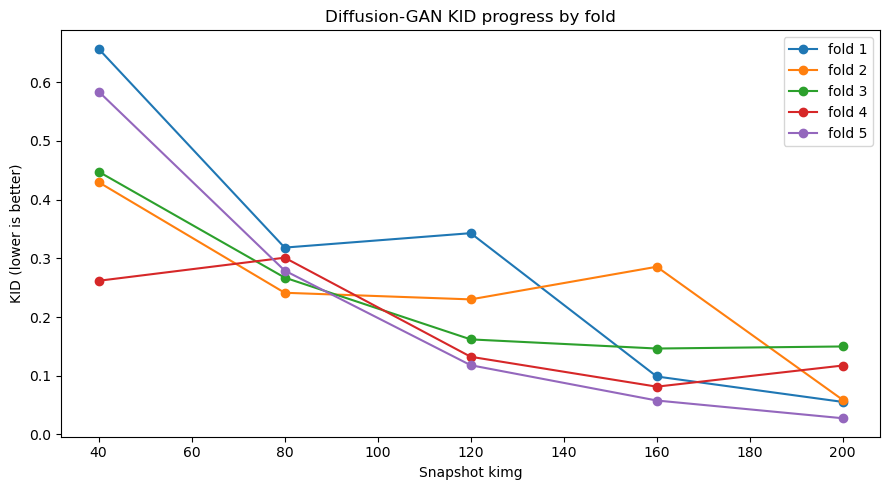

In [7]:
# We read the online KID results from training and select the lowest-KID sparse snapshot per fold.
kid_snapshot_rows = []
kid_rows = []
training_lookup = {int(row["fold_id"]): row for row in training_rows}

def parse_snapshot_kimg(snapshot_path: Path) -> int:
    return int(snapshot_path.stem.replace("network-snapshot-", ""))

def read_kid_values_by_snapshot(run_dir: Path):
    metric_file = run_dir / f"metric-{KID_METRIC_NAME}.jsonl"
    if not metric_file.exists():
        raise FileNotFoundError(f"Missing metric log: {metric_file}")

    kid_values = {}
    lines = [line for line in metric_file.read_text(encoding="utf-8").splitlines() if line.strip()]
    for line in lines:
        record = json.loads(line)
        if "results" not in record or "snapshot_pkl" not in record:
            continue
        kid_value = record["results"].get(KID_METRIC_NAME)
        if kid_value is None:
            continue
        kid_values[record["snapshot_pkl"]] = kid_value
    return kid_values

for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    run_dir = REPO_ROOT / training_lookup[fold_id]["run_dir"]
    candidate_snapshot_kimg = set(SNAPSHOT_SELECTION_KIMG)
    snapshot_paths = [
        path for path in sorted(run_dir.glob("network-snapshot-*.pkl"))
        if parse_snapshot_kimg(path) in candidate_snapshot_kimg
    ]
    if not snapshot_paths:
        raise FileNotFoundError(
            f"No snapshots from {SNAPSHOT_SELECTION_KIMG} kimg were found for fold {fold_id}"
        )
    kid_values = read_kid_values_by_snapshot(run_dir)

    fold_snapshot_rows = []
    for snapshot_path in snapshot_paths:
        kid_value = kid_values.get(snapshot_path.name)
        if kid_value is None:
            raise ValueError(f"No online KID value was found for fold {fold_id} at {snapshot_path.name}")

        fold_snapshot_rows.append({
            "fold_id": fold_id,
            "snapshot_path": as_repo_relative(REPO_ROOT, snapshot_path),
            "snapshot_kimg": parse_snapshot_kimg(snapshot_path),
            "kid50k_full": kid_value,
        })

    available_kimg = sorted(row["snapshot_kimg"] for row in fold_snapshot_rows)
    if available_kimg != SNAPSHOT_SELECTION_KIMG:
        raise RuntimeError(f"Fold {fold_id} Diffusion-GAN snapshots are {available_kimg}, expected {SNAPSHOT_SELECTION_KIMG}.")

    kid_snapshot_rows.extend(fold_snapshot_rows)
    best_row = sorted(fold_snapshot_rows, key=lambda row: (row["kid50k_full"], row["snapshot_kimg"]))[0]
    kid_rows.append(best_row)

write_csv_rows(NOTEBOOK_RESULTS_DIR / "kid_snapshot_results.csv", kid_snapshot_rows, list(kid_snapshot_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "kid_results.csv", kid_rows, list(kid_rows[0].keys()))
kid_snapshot_df = pd.DataFrame(kid_snapshot_rows)
kid_df = pd.DataFrame(kid_rows)
display(kid_snapshot_df)
display(kid_df)

# This figure shows how KID moved across the fixed sparse snapshots inside each fold.
fig, axis = plt.subplots(figsize=(9, 5))
for fold_id in sorted(kid_snapshot_df["fold_id"].unique()):
    current = kid_snapshot_df[kid_snapshot_df["fold_id"] == fold_id].sort_values("snapshot_kimg")
    axis.plot(current["snapshot_kimg"], current["kid50k_full"], marker="o", label=f"fold {fold_id}")
axis.set_xlabel("Snapshot kimg")
axis.set_ylabel("KID (lower is better)")
axis.set_title("Diffusion-GAN KID progress by fold")
axis.legend()
fig.tight_layout()
fig.savefig(NOTEBOOK_RESULTS_DIR / "kid_progress_by_fold.png", dpi=200)
plt.show()

In [ ]:
# We generate exactly the number of synthetic minority images needed to balance each training fold.
kid_lookup = {int(row["fold_id"]): row for row in kid_rows}
generated_rows_256 = []
generation_report_rows = []

for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    snapshot_path = REPO_ROOT / kid_lookup[fold_id]["snapshot_path"]
    generated_256_dir = GAN_IMAGES_256_DIR / f"fold_{fold_id}"
    safe_prepare_output_dir(generated_256_dir)

    needed_count = int(fold_plan["needed_gan_count_224"])
    start_seed = GENERATE_START_SEED + (fold_id * 10000)
    end_seed = start_seed + needed_count - 1
    seed_text = f"{start_seed}-{end_seed}"
    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"
    generate_log_path = fold_result_dir / "generate.log"

    report = run_command(
        build_diffusion_gan_command(
            "generate.py",
            f"--network={snapshot_path}",
            f"--outdir={generated_256_dir}",
            f"--seeds={seed_text}",
        ),
        DIFFUSION_GAN_DIR,
        live_log_path=generate_log_path,
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=DIFFUSION_GAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "generate_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"Diffusion-GAN generation failed for fold {fold_id}")

    generated_files = sorted(generated_256_dir.glob("seed*.png"))
    if len(generated_files) != needed_count:
        raise AssertionError(
            f"Fold {fold_id} should have {needed_count} generated 256 images, but found {len(generated_files)}."
        )

    generation_report_rows.append({
        "fold_id": fold_id,
        "selected_snapshot_kimg": int(kid_lookup[fold_id]["snapshot_kimg"]),
        "selected_kid50k_full": float(kid_lookup[fold_id]["kid50k_full"]),
        "needed_gan_count_224": needed_count,
        "generated_count_256": len(generated_files),
        "generate_duration_seconds": report["duration_seconds"],
    })

    test_fold_ids = [value for value in FOLDS_TO_RUN if value != fold_id]
    test_fold_text = ",".join(str(value) for value in test_fold_ids)
    for generated_file in generated_files:
        seed_value = int(generated_file.stem.replace("seed", ""))
        generated_rows_256.append({
            "dataset_name": DATASET_NAME,
            "gan_image_id": f"diffusion_gan_dibas_fold{fold_id}_seed{seed_value}_256",
            "fold_id": fold_id,
            "round_id": fold_id,
            "train_fold_id": fold_id,
            "test_fold_ids": test_fold_text,
            "binary_label": 0,
            "binary_group": "cocci",
            "seed": seed_value,
            "image_size": GAN_PATCH_SIZE,
            "file_path": as_repo_relative(REPO_ROOT, generated_file),
            "snapshot_path": as_repo_relative(REPO_ROOT, snapshot_path),
            "source_type": "diffusion_gan_generated",
        })

write_csv_rows(MANIFESTS_DIR / "diffusion_gan_generated_manifest_256.csv", generated_rows_256, list(generated_rows_256[0].keys()), allow_existing=ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS)
write_csv_rows(NOTEBOOK_RESULTS_DIR / "generation_report.csv", generation_report_rows, list(generation_report_rows[0].keys()))
display(pd.DataFrame(generation_report_rows))
display(pd.DataFrame(generated_rows_256[:10]))

Loading networks from "C:\Users\FYP2610\Downloads\FYP2\checkpoints\39_train_diffusion_gan_make_images_dibas\fold_1\00000-fold_1_minority_256-mirror-auto1-batch8-target0.6-ada_kimg100-ts_dist-priority-image_augno-noise_sd0.05-diffusion_gan_dibas_fold_1\network-snapshot-000200.pkl"...
Generating image for seed 20000 (0/270) ...
Setting up PyTorch plugin "bias_act_plugin"... Done.


,fold_id,needed_gan_count_224,generated_count_224,selected_snapshot_kimg,selected_kid50k_full
0,1,270,270,200,0.055340
1,2,270,270,200,0.058766
2,3,270,270,160,0.146319
3,4,270,270,160,0.081344
4,5,270,270,200,0.027531


,dataset_name,gan_image_id,fold_id,round_id,train_fold_id,test_fold_ids,binary_label,binary_group,seed,image_size,file_path,source_file_256,snapshot_path,source_type
0,dibas,diffusion_gan_dibas_fold1_seed20000_224,1,1,1,"2,3,4,5",0,cocci,20000,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
1,dibas,diffusion_gan_dibas_fold1_seed20001_224,1,1,1,"2,3,4,5",0,cocci,20001,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
2,dibas,diffusion_gan_dibas_fold1_seed20002_224,1,1,1,"2,3,4,5",0,cocci,20002,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
3,dibas,diffusion_gan_dibas_fold1_seed20003_224,1,1,1,"2,3,4,5",0,cocci,20003,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
4,dibas,diffusion_gan_dibas_fold1_seed20004_224,1,1,1,"2,3,4,5",0,cocci,20004,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
5,dibas,diffusion_gan_dibas_fold1_seed20005_224,1,1,1,"2,3,4,5",0,cocci,20005,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
6,dibas,diffusion_gan_dibas_fold1_seed20006_224,1,1,1,"2,3,4,5",0,cocci,20006,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
7,dibas,diffusion_gan_dibas_fold1_seed20007_224,1,1,1,"2,3,4,5",0,cocci,20007,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
8,dibas,diffusion_gan_dibas_fold1_seed20008_224,1,1,1,"2,3,4,5",0,cocci,20008,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated
9,dibas,diffusion_gan_dibas_fold1_seed20009_224,1,1,1,"2,3,4,5",0,cocci,20009,224,gan_images_224/diffusion_gan/dibas/fold_1/seed...,gan_images_256/diffusion_gan/dibas/fold_1/seed...,checkpoints/39_train_diffusion_gan_make_images...,diffusion_gan_generated


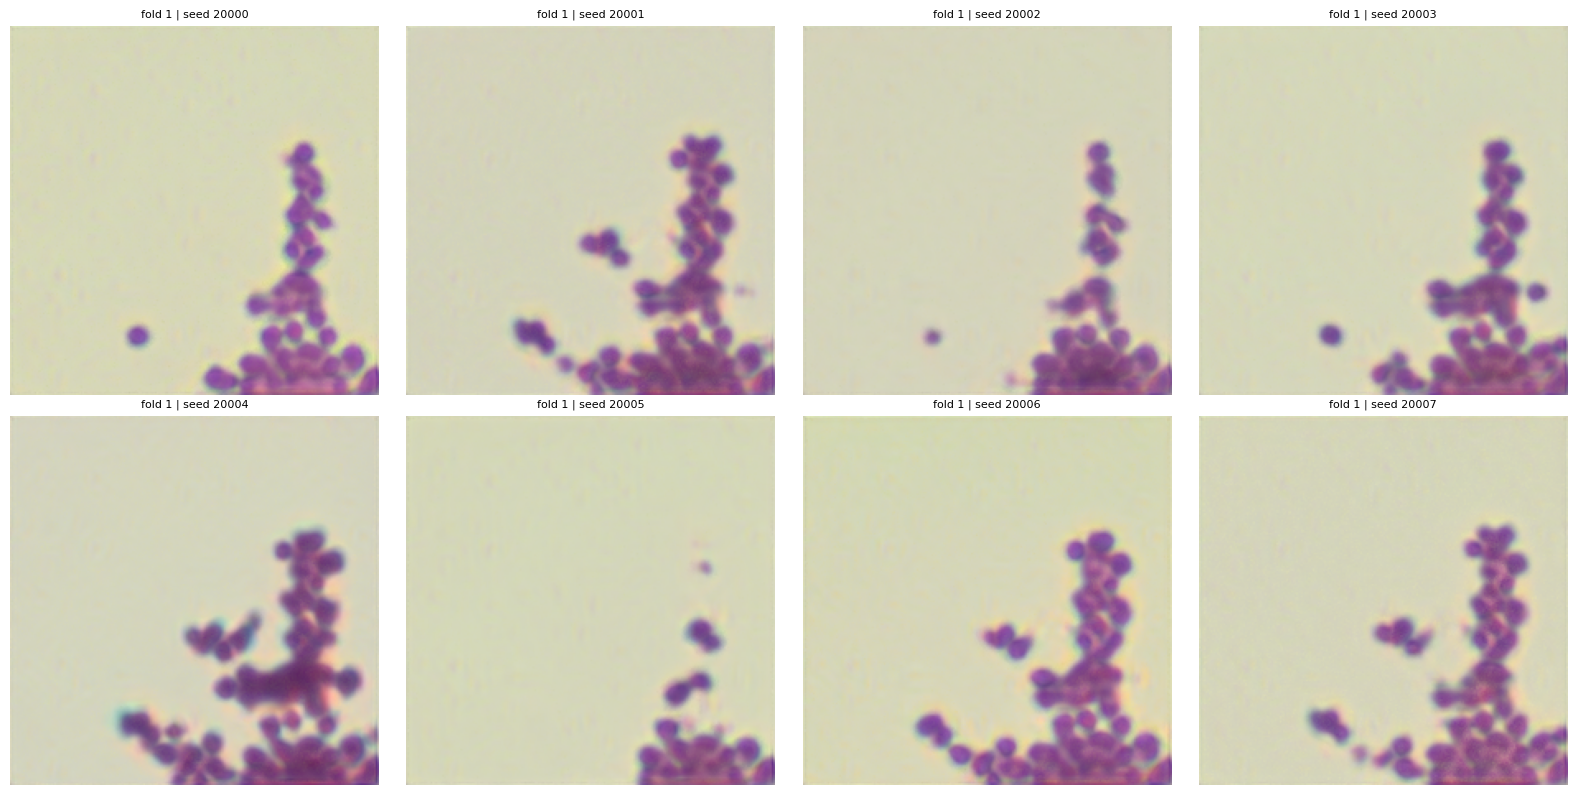

Saved generated 224 manifest to: C:\Users\FYP2610\Downloads\FYP2\manifests\diffusion_gan_generated_manifest_224.csv


In [9]:
# We resize every generated image to the fixed 224x224 CNN input size.
generated_rows_224 = []
for row in generated_rows_256:
    fold_id = int(row["fold_id"])
    source_file = REPO_ROOT / row["file_path"]
    target_dir = GAN_IMAGES_224_DIR / f"fold_{fold_id}"
    target_dir.mkdir(parents=True, exist_ok=True)
    target_file = target_dir / source_file.name
    if target_file.exists() and not ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS:
        raise FileExistsError(
            f"Refusing to overwrite existing Diffusion-GAN 224 image: {target_file}. "
            "Set ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS=True only if you intentionally rerun this notebook."
        )

    with Image.open(source_file) as image_handle:
        image = image_handle.convert("RGB")
        resized_image = image.resize((CNN_PATCH_SIZE, CNN_PATCH_SIZE), Image.Resampling.LANCZOS)
        resized_image.save(target_file)

    generated_rows_224.append({
        "dataset_name": row["dataset_name"],
        "gan_image_id": row["gan_image_id"].replace("_256", "_224"),
        "fold_id": row["fold_id"],
        "round_id": row["round_id"],
        "train_fold_id": row["train_fold_id"],
        "test_fold_ids": row["test_fold_ids"],
        "binary_label": row["binary_label"],
        "binary_group": row["binary_group"],
        "seed": row["seed"],
        "image_size": CNN_PATCH_SIZE,
        "file_path": as_repo_relative(REPO_ROOT, target_file),
        "source_file_256": row["file_path"],
        "snapshot_path": row["snapshot_path"],
        "source_type": row["source_type"],
    })

write_csv_rows(MANIFESTS_DIR / "diffusion_gan_generated_manifest_224.csv", generated_rows_224, list(generated_rows_224[0].keys()), allow_existing=ALLOW_OVERWRITE_DIFFUSION_GAN_OUTPUTS)

summary = {
    "notebook_tag": NOTEBOOK_TAG,
    "dataset_name": DATASET_NAME,
    "seed": SEED,
    "diffusion_gan_random_seed": DIFFUSION_GAN_RANDOM_SEED,
    "gan_patch_size": GAN_PATCH_SIZE,
    "cnn_patch_size": CNN_PATCH_SIZE,
    "gan_batch_size": GAN_BATCH_SIZE,
    "gan_workers": GAN_WORKERS,
    "gan_kimg": GAN_KIMG,
    "tick_kimg_expected": TICK_KIMG,
    "snap_ticks": SNAP_TICKS,
    "snapshot_selection_kimg": SNAPSHOT_SELECTION_KIMG,
    "gan_mirror": GAN_MIRROR,
    "diffusion_gan_cfg": DIFFUSION_GAN_CFG,
    "diffusion_gan_aug": DIFFUSION_GAN_AUG,
    "diffusion_gan_target": DIFFUSION_GAN_TARGET,
    "diffusion_gan_noise_sd": DIFFUSION_GAN_NOISE_SD,
    "diffusion_gan_ts_dist": DIFFUSION_GAN_TS_DIST,
    "diffusion_gan_ada_kimg": DIFFUSION_GAN_ADA_KIMG,
    "kid_metric_name": KID_METRIC_NAME,
    "generated_manifest_256": as_repo_relative(REPO_ROOT, MANIFESTS_DIR / "diffusion_gan_generated_manifest_256.csv"),
    "generated_manifest_224": as_repo_relative(REPO_ROOT, MANIFESTS_DIR / "diffusion_gan_generated_manifest_224.csv"),
    "compatibility_patch_report": as_repo_relative(REPO_ROOT, NOTEBOOK_RESULTS_DIR / "diffusion_gan_compatibility_patch_report.json"),
}
write_json(NOTEBOOK_RESULTS_DIR / "summary.json", summary)

fold_result_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    generated_count = sum(1 for row in generated_rows_224 if int(row["fold_id"]) == fold_id)
    fold_result_rows.append({
        "fold_id": fold_id,
        "needed_gan_count_224": int(fold_plan["needed_gan_count_224"]),
        "generated_count_224": generated_count,
        "selected_snapshot_kimg": int(kid_lookup[fold_id]["snapshot_kimg"]),
        "selected_kid50k_full": float(kid_lookup[fold_id]["kid50k_full"]),
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "gan_summary_by_fold.csv", fold_result_rows, list(fold_result_rows[0].keys()))
display(pd.DataFrame(fold_result_rows))
display(pd.DataFrame(generated_rows_224[:10]))

# This preview helps us audit that the resized synthetic patches look sensible.
preview_rows = generated_rows_224[:8]
if preview_rows:
    figure_columns = min(4, len(preview_rows))
    figure_rows = math.ceil(len(preview_rows) / figure_columns)
    fig, axes = plt.subplots(figure_rows, figure_columns, figsize=(4 * figure_columns, 4 * figure_rows))
    try:
        flat_axes = axes.flatten().tolist()
    except AttributeError:
        flat_axes = [axes]
    for axis, row in zip(flat_axes, preview_rows):
        image_path = REPO_ROOT / row["file_path"]
        with Image.open(image_path) as image_handle:
            axis.imshow(image_handle.convert("RGB"))
        axis.set_title(f"fold {row['fold_id']} | seed {row['seed']}", fontsize=8)
        axis.axis("off")
    for axis in flat_axes[len(preview_rows):]:
        axis.axis("off")
    fig.tight_layout()
    fig.savefig(NOTEBOOK_RESULTS_DIR / "generated_preview_224.png", dpi=200)
    plt.show()
print(f"Saved generated 224 manifest to: {MANIFESTS_DIR / 'diffusion_gan_generated_manifest_224.csv'}")